# The Family Tree \U0001F333
### Cluster the assets, split risk down the branches, never invert a matrix

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Fragile](https://img.shields.io/badge/Usefulness-Fragile-dab617?style=flat-square)

A portfolio optimiser inverts the covariance matrix, and inverting a badly estimated matrix is
how you end up 40% long one stock and short three others. Hierarchical risk parity refuses to
invert anything: it draws a family tree of the assets and divides risk down the branches. This
notebook builds it from scratch and asks what the tree is actually worth.

> \U0001F4D3 **This is the plain-language layer.** The linkage algebra, the paired tests and
> the Monte Carlo are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does HRP beat the optimiser out of sample? | On the wide panel, yes — quieter, steadier, no shorts. |
| Is that because of the clustering? | Mostly not. Plain inverse-variance weighting gets nearly all of it. |
| So is the tree useless? | No — it moves a measurable share of the book and it is what stops a crowded cluster dominating. Just do not credit it with the whole gain. |
| Would you run it? | For a long-only book with a thin covariance matrix, it is a reasonable default that cannot blow up. |

## 1 · The claim

> *"Markowitz's curse: the more correlated the assets, the more unstable the optimiser's
> weights. Hierarchical clustering solves it by never inverting the matrix at all."*

That is López de Prado's argument, and the first half of it is unambiguously true.

In [2]:
from hrp import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
panels = {
    "sectors": [c for c in data.SECTORS if rets[c].notna().sum() > 1500],
    "names": [c for c in data.NAMES if rets[c].notna().sum() > 3000],
    "multi-asset": [c for c in data.MULTI if rets[c].notna().sum() > 3000],
}
print(f"as-of {data.AS_OF}")
for tag, cols in panels.items():
    print(f"  {tag:12s} {len(cols):3d} assets")

as-of 2026-06-30
  sectors       11 assets
  names         40 assets
  multi-asset   10 assets


## 2 · The tree, drawn

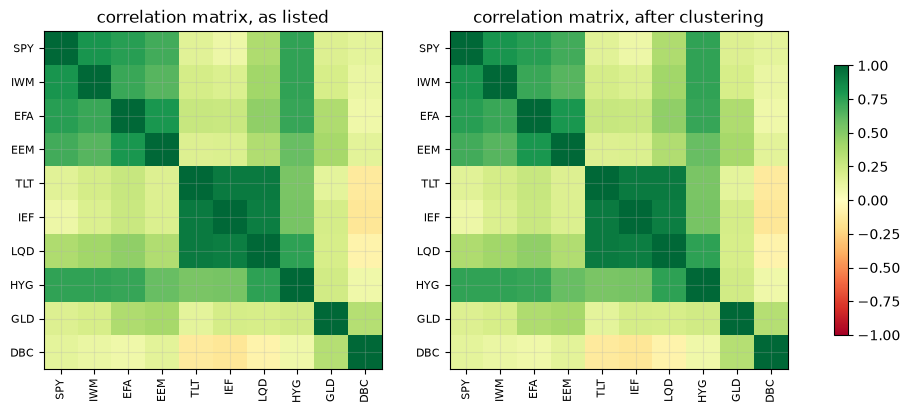

leaf order: SPY, IWM, EFA, EEM, TLT, IEF, LQD, HYG, GLD, DBC


In [3]:
cols = panels["multi-asset"]
sub = rets[cols].dropna(how="any")
cov = np.cov(sub.iloc[-756:].to_numpy(), rowvar=False, ddof=1)
order = st.cluster_order(cov)
sd = np.sqrt(np.diag(cov)); corr = cov / np.outer(sd, sd)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, idx, title in ((axes[0], list(range(len(cols))), "as listed"),
                       (axes[1], order, "after clustering")):
    im = ax.imshow(corr[np.ix_(idx, idx)], cmap="RdYlGn", vmin=-1, vmax=1)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels([cols[i] for i in idx], rotation=90, fontsize=8)
    ax.set_yticks(range(len(cols))); ax.set_yticklabels([cols[i] for i in idx], fontsize=8)
    ax.set_title(f"correlation matrix, {title}")
fig.colorbar(im, ax=axes, shrink=0.7)
plt.show()
print("leaf order:", ", ".join(cols[i] for i in order))

The right-hand panel is the same matrix with the rows and columns permuted so relatives sit
together — bonds with bonds, equities with equities. That reordering is the whole of step two,
and everything HRP does afterwards reads the matrix as if it were block-diagonal.

## 3 · The weights it produces

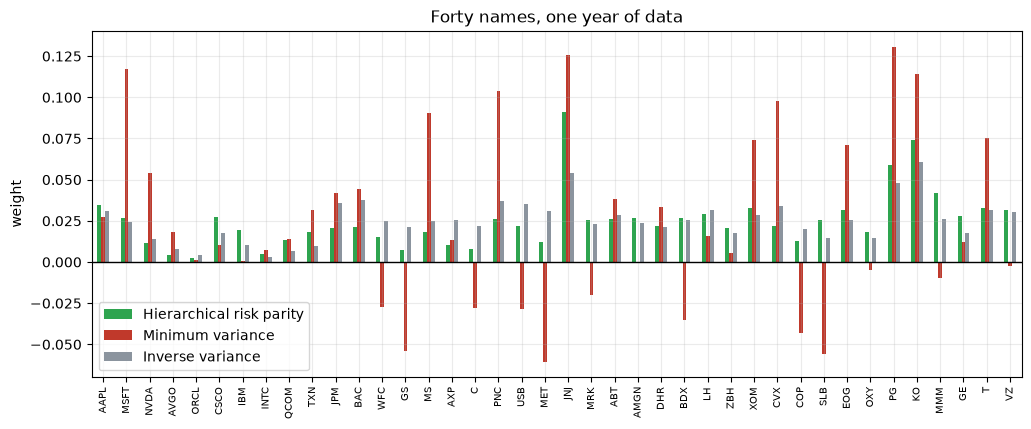

     Hierarchical risk parity  Minimum variance  Inverse variance  Equal risk contribution    1/N
max                    0.0910            0.1310            0.0610                   0.0970 0.0250
min                    0.0020           -0.0600            0.0030                   0.0000 0.0250


In [4]:
cols = panels["names"]
sub = rets[cols].dropna(how="any")
cov = np.cov(sub.iloc[-252:].to_numpy(), rowvar=False, ddof=1)
W = pd.DataFrame({st.METHOD_LABEL[m]: st.weights_for(m, cov) for m in st.METHODS}, index=cols)
fig, ax = plt.subplots(figsize=(12, 4.5))
W[[st.METHOD_LABEL[m] for m in ("hrp", "min_var", "inv_var")]].plot.bar(
    ax=ax, color=["#2ea44f", "#c0392b", "#8b949e"])
ax.axhline(0, color="k", lw=1); ax.set_ylabel("weight")
ax.set_title("Forty names, one year of data")
ax.legend(title=""); plt.setp(ax.get_xticklabels(), fontsize=7)
plt.show()
print(W.agg(["max", "min"]).round(3).to_string())

> \U0001F52C **For the quants.** The optimiser's bar chart is the one with negative bars and a
> couple of very tall ones. HRP's is flat, positive and boring — which is the point, and also
> the reason it is hard to tell apart from inverse variance.

## 4 · Out of sample

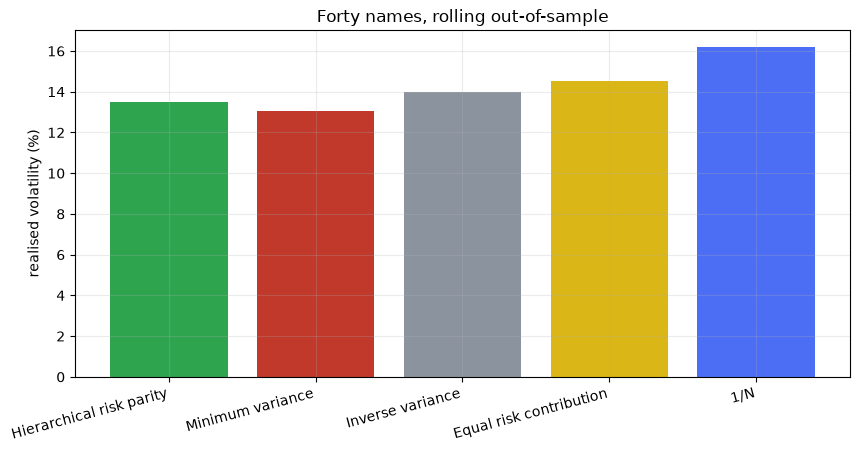

,realised_vol,sharpe,turnover,max_weight,effective_n,short
method,,,,,,
hrp,0.1350,0.9350,0.2710,0.0840,26.5050,0.0000
min_var,0.1310,0.6470,1.5380,0.3160,3.3010,0.8390
inv_var,0.1400,0.9270,0.1190,0.0670,30.8890,0.0000
risk_parity,0.1450,0.9730,0.0860,0.0520,35.1880,0.0000
equal,0.1620,0.9790,0.0160,0.0250,40.0000,0.0000


In [5]:
wf = st.walk_forward(sub, window=252, step=63, cost_bps=5.0)
s = st.summarise(wf)
fig, ax = plt.subplots(figsize=(10, 4.5))
colors = {"hrp": "#2ea44f", "min_var": "#c0392b", "inv_var": "#8b949e",
          "risk_parity": "#dab617", "equal": "#4c6ef5"}
ax.bar([st.METHOD_LABEL[m] for m in s.index], s["realised_vol"] * 100,
       color=[colors[m] for m in s.index])
ax.set_ylabel("realised volatility (%)")
ax.set_title("Forty names, rolling out-of-sample")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.show()
s[["realised_vol", "sharpe", "turnover", "max_weight", "effective_n", "short"]].round(3)

## 5 · The verdict

**Signal: Real.** The tree is not decoration: HRP's weights differ from plain inverse-variance weights by **16.7%** of the book on the 40-name panel and 9.3% on the multi-asset one, and the clustering changes the ordering on 3 of 3 panels. What it buys is a different question: HRP holds an effective **26.5** positions against 3.3 for the optimiser, with a maximum weight of 8.4% against 31.6% and no shorts at all.

**Usefulness: Fragile.** On the wide panel HRP realises **13.47%** annualised against **13.07%** for minimum variance (paired *t* = -1.01) and **16.20%** for 1/N (*t* = +11.20). Against the control that matters — inverse variance, which is HRP without the tree — the difference is -0.527% (*t* = +6.50). Turnover is 0.27 a rebalance against 1.54, which is where the practical case for it is strongest.

## 6 · Going further \U0001F6AA

- **HRP against a *shrunk* optimiser** (study 975) is the comparison the literature usually
  avoids, and the one that decides whether the tree or the estimator is doing the work.
- **Other linkages** (average, Ward) and other distances change the tree; Raffinot (2017)
  found the choice matters less than the clustering itself.
- **Tail dependence** instead of correlation as the distance — Lohre et al. (2020).